# Flyers Modeling

## Read in data

In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid

import xgboost as xgb
import lightgbm as lgb

In [2]:
df = pd.read_csv("../data/flyers_square_modeling_df.csv", index_col=0)
df.drop(columns=['region', # captured by lat and lng
                 'OppScore', # captured by Team Score and Point diff
                 'Home', # all are home games
                 'Penguins', # captured by opponent
                 'Rangers', # captured by opponent
                 'Devils', # captured by opponent
                 'xStartTime', # Captured by start hour
                 "xEndTime" # Captured by end hour;
                 ]
        , inplace=True)

df

,date,hour,stop_count,Game,Day,xLOG,Attendance,Opp,TeamScore,PointDiff,...,Losses,Streak,Rivalry,RegularSeason,ConfQF,start_hour,end_hour,game_period,lat,lng
9648,2014-01-02,0,0,41.0,Thursday,150.0,NaN,Colorado Avalanche,1.0,-1.0,...,17.0,-1.0,0.0,1.0,0.0,19,22,before,4434,-6395
9649,2014-01-02,0,0,41.0,Thursday,150.0,NaN,Colorado Avalanche,1.0,-1.0,...,17.0,-1.0,0.0,1.0,0.0,19,22,before,4434,-6394
9650,2014-01-02,0,0,41.0,Thursday,150.0,NaN,Colorado Avalanche,1.0,-1.0,...,17.0,-1.0,0.0,1.0,0.0,19,22,before,4438,-6399
9651,2014-01-02,0,1,41.0,Thursday,150.0,NaN,Colorado Avalanche,1.0,-1.0,...,17.0,-1.0,0.0,1.0,0.0,19,22,before,4435,-6398
9652,2014-01-02,0,0,41.0,Thursday,150.0,NaN,Colorado Avalanche,1.0,-1.0,...,17.0,-1.0,0.0,1.0,0.0,19,22,before,4436,-6399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15089467,2018-04-13,23,0,2.0,Friday,155.0,18648.0,Pittsburgh Penguins,5.0,4.0,...,1.0,1.0,1.0,0.0,1.0,19,22,after,4427,-6392
15089468,2018-04-13,23,0,2.0,Friday,155.0,18648.0,Pittsburgh Penguins,5.0,4.0,...,1.0,1.0,1.0,0.0,1.0,19,22,after,4450,-6397
15089469,2018-04-13,23,0,2.0,Friday,155.0,18648.0,Pittsburgh Penguins,5.0,4.0,...,1.0,1.0,1.0,0.0,1.0,19,22,after,4449,-6396
15089470,2018-04-13,23,0,2.0,Friday,155.0,18648.0,Pittsburgh Penguins,5.0,4.0,...,1.0,1.0,1.0,0.0,1.0,19,22,after,4446,-6401


In [3]:
df.columns

Index(['date', 'hour', 'stop_count', 'Game', 'Day', 'xLOG', 'Attendance',
       'Opp', 'TeamScore', 'PointDiff', 'Win', 'OT', 'SO', 'Season', 'Wins',
       'Losses', 'Streak', 'Rivalry', 'RegularSeason', 'ConfQF', 'start_hour',
       'end_hour', 'game_period', 'lat', 'lng'],
      dtype='object')

## Define features and one-hot encode categorical variables

In [4]:
features = ['hour', 'Game', 'Day', 'xLOG', 'Attendance',
       'Opp', 'TeamScore', 'PointDiff', 'Win', 'OT', 'SO', 'Season', 'Wins',
       'Losses', 'Streak', 'Rivalry', 'RegularSeason', 'ConfQF', 'start_hour',
       'end_hour', 'game_period', 'lat', 'lng']

X = df[features].copy()
y = df['stop_count']

# Convert categorical text/objects into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Day', 'Opp',  'Season', 'game_period'],
                   drop_first=True,
                   dtype=int)

X

,hour,Game,xLOG,Attendance,TeamScore,PointDiff,Win,OT,SO,Wins,...,Opp_Vancouver Canucks,Opp_Vegas Golden Knights,Opp_Washington Capitals,Opp_Winnipeg Jets,Season_2014.0,Season_2015.0,Season_2016.0,Season_2017.0,game_period_before,game_period_during
9648,0,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
9649,0,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
9650,0,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
9651,0,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
9652,0,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15089467,23,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
15089468,23,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
15089469,23,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
15089470,23,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0


## Split data into training, validation, testing (grouped on date, hour)

In [5]:
from sklearn.model_selection import GroupShuffleSplit

# Create a unique ID for each date + hour
df['group_id'] = df['date'].astype(str) + "_" + df['hour'].astype(str)

# Use GroupShuffleSplit instead of regular train_test_split

#  Split out test set (20%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(X, y, groups=df['group_id']))

X_train_val = X.iloc[train_val_idx]
y_train_val = y.iloc[train_val_idx]
groups_train_val = df['group_id'].iloc[train_val_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

# Split train_val into train (70) and validation (10)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups=groups_train_val))

X_train = X_train_val.iloc[train_idx]
y_train = y_train_val.iloc[train_idx]

X_val = X_train_val.iloc[val_idx]
y_val = y_train_val.iloc[val_idx]


In [6]:
print(len(X_val), len(X_test), len(X_train))

185322 370644 1296450


In [7]:
X_val

,hour,Game,xLOG,Attendance,TeamScore,PointDiff,Win,OT,SO,Wins,...,Opp_Vancouver Canucks,Opp_Vegas Golden Knights,Opp_Washington Capitals,Opp_Winnipeg Jets,Season_2014.0,Season_2015.0,Season_2016.0,Season_2017.0,game_period_before,game_period_during
11256,4,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
11257,4,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
11258,4,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
11259,4,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
11260,4,41.0,150.0,NaN,1.0,-1.0,0.0,0.0,0.0,20.0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15089065,22,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,1
15089066,22,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,1
15089067,22,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,1
15089068,22,2.0,155.0,18648.0,5.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,1


In [8]:
y_val

11256       0
11257       0
11258       0
11259       0
11260       0
           ..
15089065    0
15089066    0
15089067    0
15089068    0
15089069    0
Name: stop_count, Length: 185322, dtype: int64

## Fit Different Models on Validation Set

### Define Evaluation Function

In [9]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    preds_int = np.rint(preds).astype(int)
    mae = mean_absolute_error(y, preds_int)
    rmse = np.sqrt(mean_squared_error(y, preds_int))
    return mae, rmse


### Define Feature Sets

In [10]:
feature_sets = {
    "all_features": X_val.columns.tolist(),
    "top_features": ["lng", "lat", "hour", 'Day_Monday',
       'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday',
       'Day_Wednesday']
}


### Define Hyperparameter Grids

In [11]:
xgb_params = {
    "n_estimators": [100, 300],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

rf_params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
}

lgb_params = {
    "n_estimators": [100, 300],
    "num_leaves": [31, 50],
    "learning_rate": [0.05, 0.1],
}

### Try the different models

In [12]:
results = []

for feature_set_name, features in feature_sets.items():

    X_tr = X_train[features]
    X_v = X_val[features]

    # # -------------------
    # # XGBOOST
    # # -------------------
    # for params in ParameterGrid(xgb_params):
    #     model = xgb.XGBRegressor(
    #         objective='reg:squarederror',
    #         random_state=42,
    #         **params
    #     )
    #
    #     model.fit(X_tr, y_train)
    #     mae, rmse = evaluate_model(model, X_v, y_val)
    #
    #     results.append({
    #         "model": "XGBoost",
    #         "feature_set": feature_set_name,
    #         "params": params,
    #         "val_mae": mae,
    #         "val_rmse": rmse
    #     })
    #
    # print(results)
    #
    # -------------------
    # RANDOM FOREST
    # -------------------
    # for params in ParameterGrid(rf_params):
    #     model = RandomForestRegressor(
    #         random_state=42,
    #         n_jobs=-1,
    #         **params
    #     )
    #
    #     model.fit(X_tr, y_train)
    #     mae, rmse = evaluate_model(model, X_v, y_val)
    #
    #     results.append({
    #         "model": "RandomForest",
    #         "feature_set": feature_set_name,
    #         "params": params,
    #         "val_mae": mae,
    #         "val_rmse": rmse
    #     })
    # print(results)
    # -------------------
    # LIGHTGBM
    # -------------------
    for params in ParameterGrid(lgb_params):
        model = lgb.LGBMRegressor(
            random_state=42,
            **params
        )

        model.fit(X_tr, y_train)
        mae, rmse = evaluate_model(model, X_v, y_val)

        results.append({
            "model": "LightGBM",
            "feature_set": feature_set_name,
            "params": params,
            "val_mae": mae,
            "val_rmse": rmse
        })
    print(results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035987 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 1296450, number of used features: 61
[LightGBM] [Info] Start training from score 0.118864
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 1296450, number of used features: 61
[LightGBM] [Info] Start training from score 0.118864
[LightGBM] [Warning] Found

### Compare Results

In [13]:
results_df = pd.DataFrame(results)

# Sort by validation MAE (or RMSE)
results_df = results_df.sort_values(by="val_rmse")

results_df


,model,feature_set,params,val_mae,val_rmse
7,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...",0.116673,0.467042
3,LightGBM,all_features,"{'learning_rate': 0.05, 'n_estimators': 300, '...",0.116516,0.469227
6,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...",0.117320,0.470954
5,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.116764,0.472196
2,LightGBM,all_features,"{'learning_rate': 0.05, 'n_estimators': 300, '...",0.117239,0.473405
1,LightGBM,all_features,"{'learning_rate': 0.05, 'n_estimators': 100, '...",0.117304,0.478022
4,LightGBM,all_features,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.117973,0.478056
15,LightGBM,top_features,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...",0.121788,0.480010
11,LightGBM,top_features,"{'learning_rate': 0.05, 'n_estimators': 300, '...",0.121178,0.480488
14,LightGBM,top_features,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...",0.121292,0.480651


### Select Best Model

In [14]:
best_row = results_df.iloc[0]

best_model_name = best_row["model"]
best_params = best_row["params"]
best_features = feature_sets[best_row["feature_set"]]

print(best_row)


model                                                   LightGBM
feature_set                                         all_features
params         {'learning_rate': 0.1, 'n_estimators': 300, 'n...
val_mae                                                 0.116673
val_rmse                                                0.467042
Name: 7, dtype: object


### Select Best model that used only non-game day features

In [15]:
top_feat_df = results_df[results_df["feature_set"] == "top_features"]
best_top_row = top_feat_df.iloc[0]

top_features = feature_sets[best_top_row["feature_set"]]
top_params = best_top_row["params"]

## SHAP (using validation set to go backwards and influence variable sets)

/Users/vijetharamdas/Documents/PhillyProject/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


      model   feature_set                                             params  \
0  LightGBM  all_features  {'learning_rate': 0.1, 'n_estimators': 300, 'n...   
1  LightGBM  all_features  {'learning_rate': 0.05, 'n_estimators': 300, '...   
2  LightGBM  all_features  {'learning_rate': 0.1, 'n_estimators': 300, 'n...   

    val_mae  val_rmse  
0  0.116673  0.467042  
1  0.116516  0.469227  
2  0.117320  0.470954  

Running SHAP for model 1: LightGBM (all_features)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 1296450, number of used features: 61
[LightGBM] [Info] Start training from score 0.118864


 97%|=================== | 4870/5000 [00:16<00:00]       

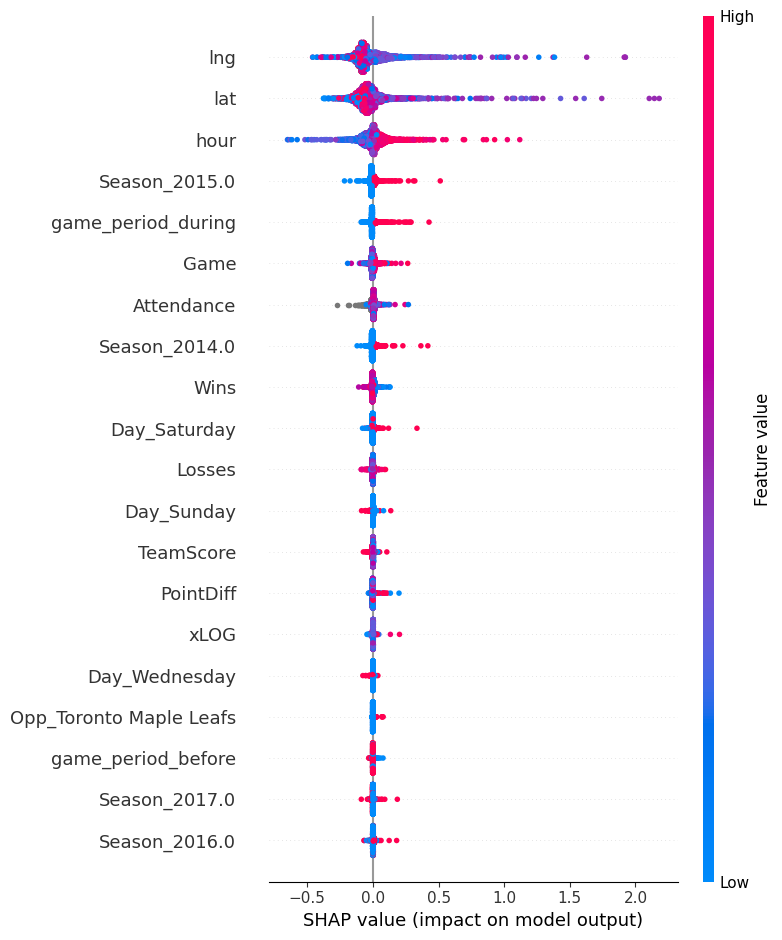

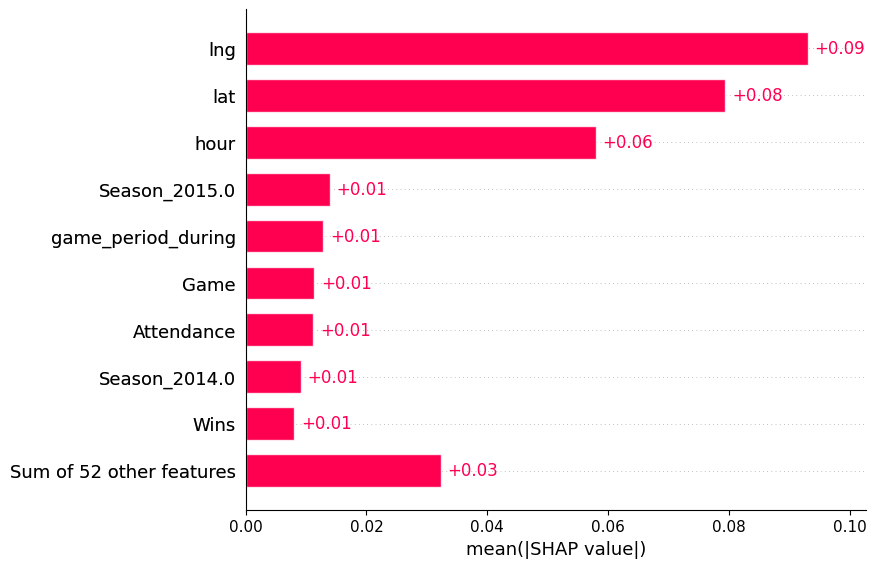


Running SHAP for model 2: LightGBM (all_features)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 1296450, number of used features: 61
[LightGBM] [Info] Start training from score 0.118864


 97%|=================== | 4841/5000 [00:22<00:00]       

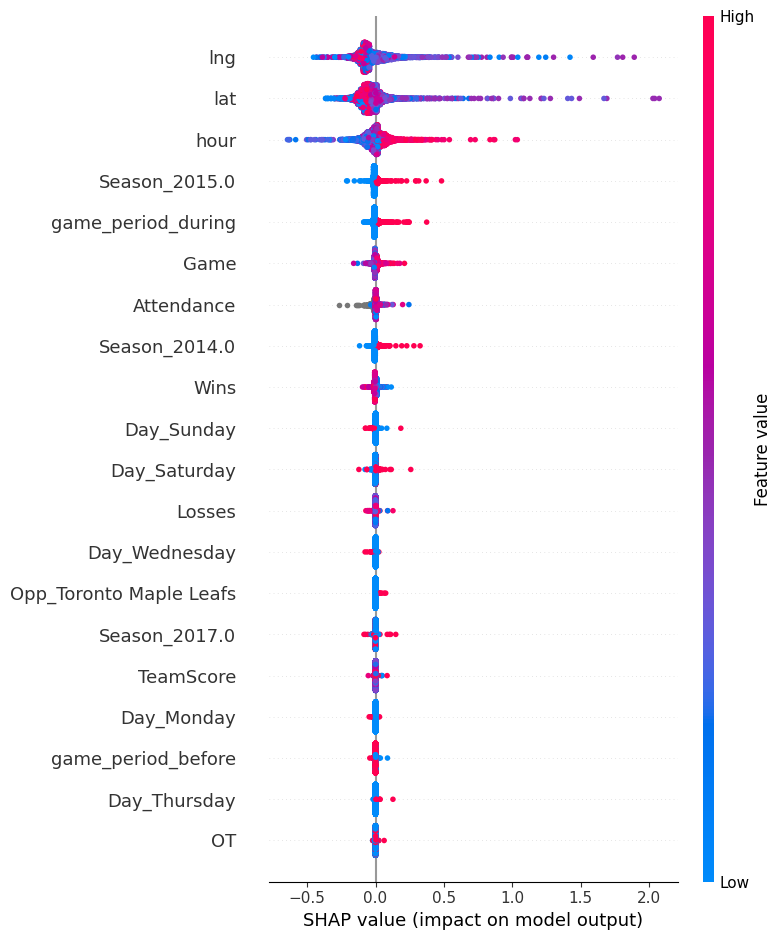

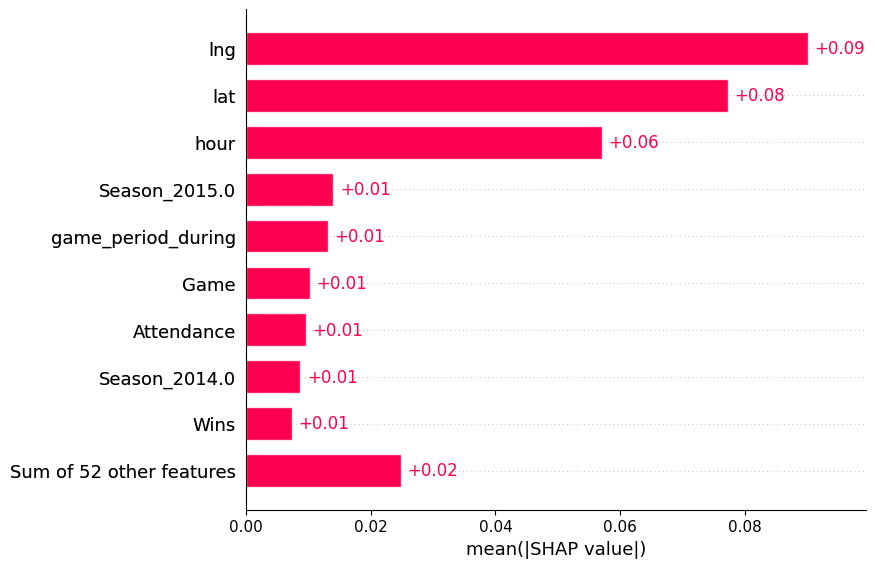


Running SHAP for model 3: LightGBM (all_features)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028299 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 1296450, number of used features: 61
[LightGBM] [Info] Start training from score 0.118864


100%|===================| 4988/5000 [00:14<00:00]        

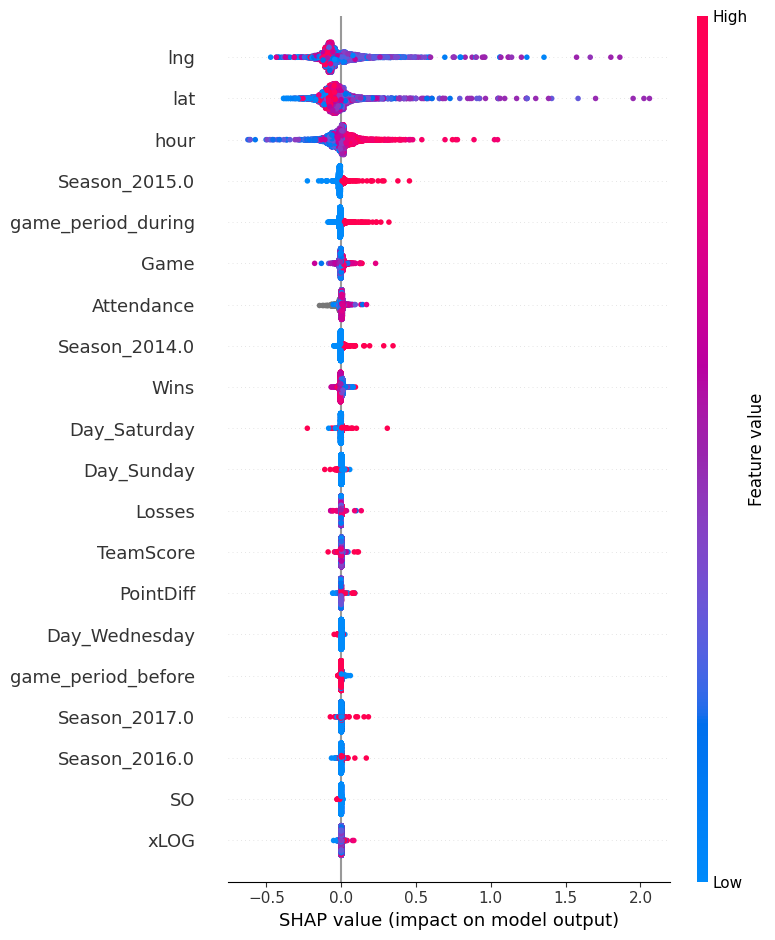

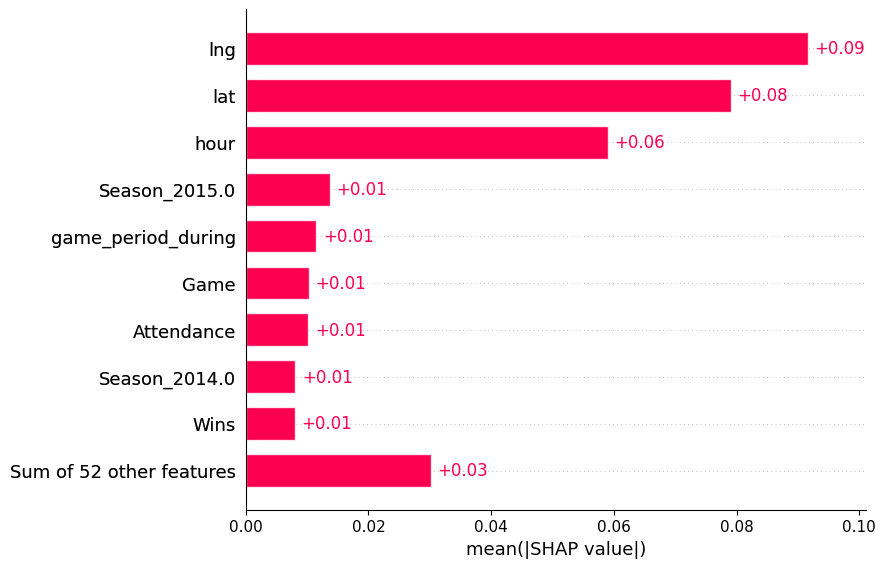

In [16]:
import shap

# Ensure sorted (just in case)
results_df = results_df.sort_values(by="val_rmse").reset_index(drop=True)

top_3 = results_df.head(3)
print(top_3)

def build_model(model_name, params):
    if model_name == "XGBoost":
        return xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            **params
        )

    elif model_name == "RandomForest":
        return RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        )

    elif model_name == "LightGBM":
        return lgb.LGBMRegressor(
            random_state=42,
            **params
        )

shap_results = []

for i, row in top_3.iterrows():

    model_name = row["model"]
    params = row["params"]
    feature_set_name = row["feature_set"]
    features = feature_sets[feature_set_name]

    print(f"\nRunning SHAP for model {i+1}: {model_name} ({feature_set_name})")

    # Prepare data
    X_tr = X_train[features]
    X_v = X_val[features]

    # Build + fit model
    model = build_model(model_name, params)
    model.fit(X_tr, y_train)

    # Sample validation set (for speed)
    X_sample = X_v.sample(n=min(5000, len(X_v)), random_state=42)

    # SHAP
    explainer = shap.Explainer(model, X_sample)
    shap_values = explainer(X_sample)

    # Store results
    shap_results.append({
        "model": model_name,
        "feature_set": feature_set_name,
        "explainer": explainer,
        "shap_values": shap_values,
        "X_sample": X_sample
    })

    # Plot summary
    shap.summary_plot(shap_values, X_sample)

    # Plot bar (clean importance)
    shap.plots.bar(shap_values)



## Fit selected model using training data

In [17]:
X_tr_final = X_train[best_features]
X_test_final = X_test[best_features]

if best_model_name == "XGBoost":
    final_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params
    )

elif best_model_name == "RandomForest":
    final_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **best_params
    )

elif best_model_name == "LightGBM":
    final_model = lgb.LGBMRegressor(
        random_state=42,
        **best_params
    )

final_model.fit(X_tr_final, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 1296450, number of used features: 61
[LightGBM] [Info] Start training from score 0.118864


,boosting_type,'gbdt'
,num_leaves,50
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Final Evaluation on Test Data

In [18]:
test_mae, test_rmse = evaluate_model(final_model, X_test_final, y_test)

print(f"Final Test MAE: {test_mae:.4f}")
print(f"Final Test RMSE: {test_rmse:.4f}")

Final Test MAE: 0.1163
Final Test RMSE: 0.4686


## Create baseline Model for Comparison

In [19]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)

# Round predictions to nearest integer
y_pred_int = np.rint(y_pred).astype(int)

# Evaluate
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_int))
base_mae = mean_absolute_error(y_test, y_pred_int)

print(f"Baseline MAE: {base_mae:.4f}")
print(f"Baseline RMSE: {base_rmse:.4f}")


Baseline MAE: 0.1178
Baseline RMSE: 0.5501


## SHAP on final model

 96%|=================== | 4794/5000 [00:16<00:00]       

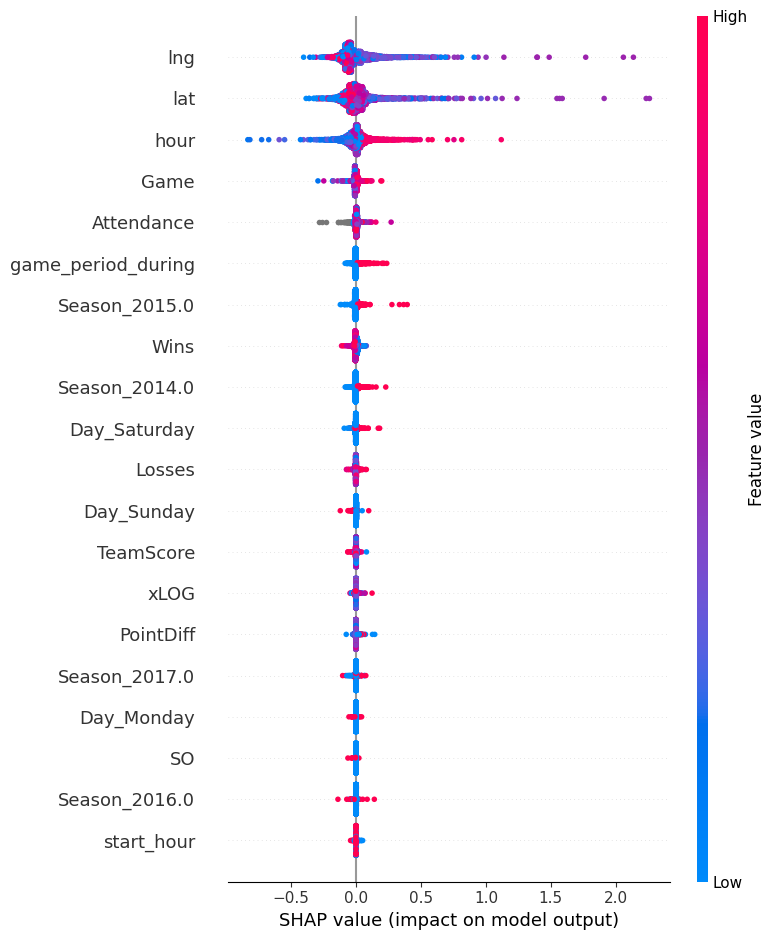

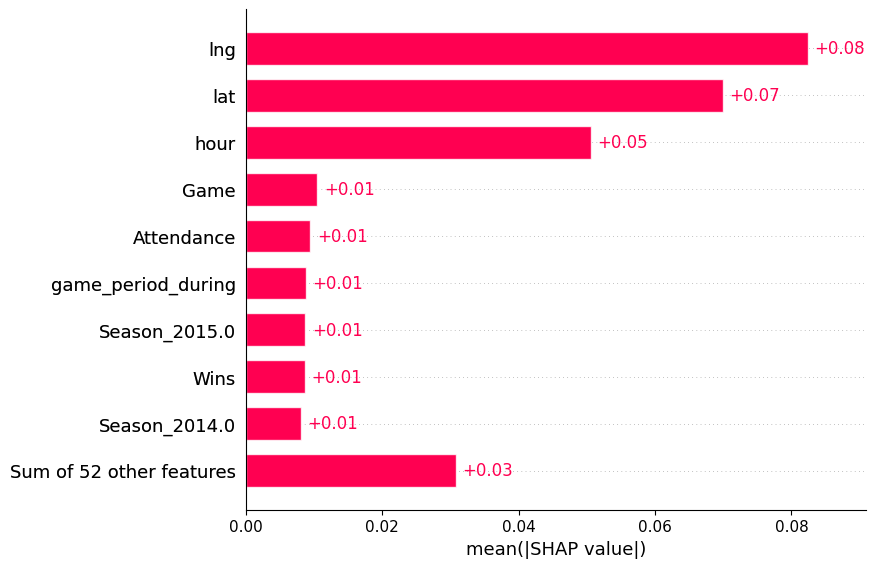

In [20]:
X_shap = X_test_final.sample(
    n=min(5000, len(X_test_final)),
    random_state=42
)

explainer = shap.Explainer(final_model, X_shap)
shap_values = explainer(X_shap)

shap.summary_plot(shap_values, X_shap)

shap.plots.bar(shap_values)
